In [105]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import os
from dotenv import load_dotenv

In [106]:
STOCK_DATA_PATH = "../data/raw/sector_etfs_daily.csv"
FRED_APIKEY = 'e97eceafe71bc6b6e1fd617a59d8d915'

In [107]:
stock_df = pd.read_csv(RAW_STOCK_PATH)

In [60]:
stock_df.head()
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    30000 non-null  object 
 1   ticker  30000 non-null  object 
 2   open    30000 non-null  float64
 3   high    30000 non-null  float64
 4   low     30000 non-null  float64
 5   close   30000 non-null  float64
 6   volume  30000 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 1.6+ MB


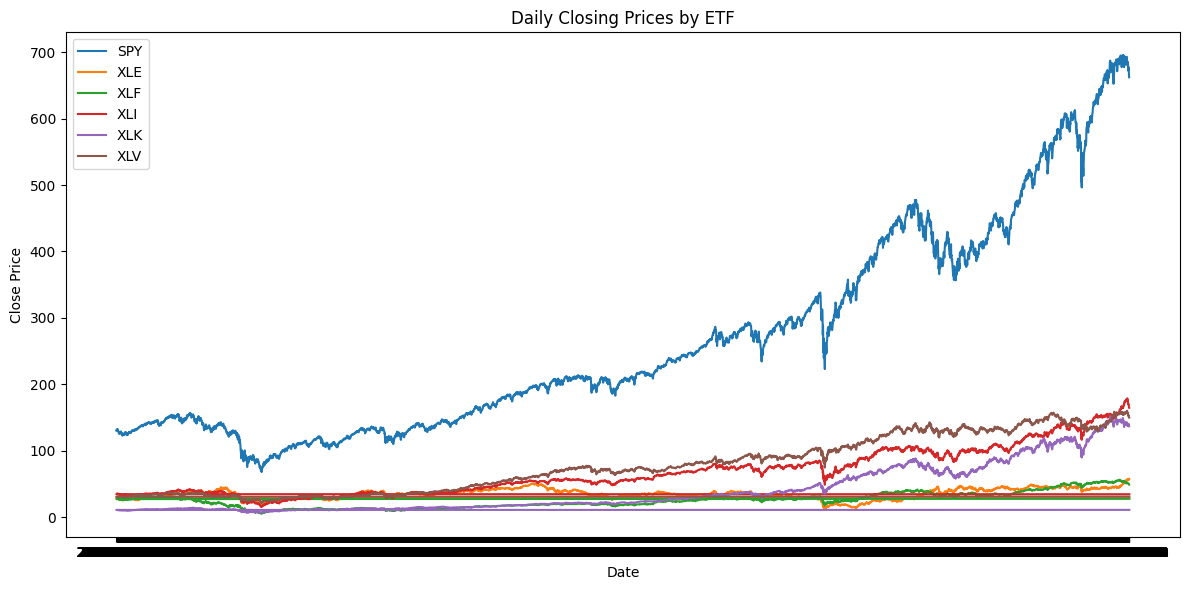

In [ ]:
plt.figure(figsize=(12, 6))
for ticker in sorted(stock_df["ticker"].unique()):
    subset = stock_df[stock_df["ticker"] == ticker]
    plt.plot(subset["date"], subset["close"], label=ticker)

plt.title("Daily Closing Prices by ETF")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
stock_df["simple_return"] = stock_df.groupby("ticker")["close"].pct_change()
stock_df["log_return"] = stock_df.groupby("ticker")["close"].transform(
    lambda s: np.log(s / s.shift(1)))
stock_df["rolling_vol_30d"] = stock_df.groupby("ticker")["log_return"].transform(
    lambda s: s.rolling(window=30).std())

In [62]:
stock_df.head()

,date,ticker,open,high,low,close,volume
0,2006-04-28,XLE,28.435,28.930,28.435000,28.570000,38107800
1,2006-05-01,XLE,28.775,29.315,28.715000,29.040001,39191600
2,2006-05-02,XLE,29.365,29.720,29.185000,29.685000,38083000
3,2006-05-03,XLE,29.570,29.680,29.004999,29.225000,51569400
4,2006-05-04,XLE,28.975,29.360,28.565000,29.090000,55618400


In [65]:
stock_df["date"] = pd.to_datetime(stock_df["date"])
stock_df["year_month"] = stock_df["date"].dt.to_period("M").astype(str)

monthly = (
    stock_df.groupby(["ticker", "year_month"], as_index=False)
    .agg(
        monthly_volatility=("log_return", "std"),
        mean_daily_return=("log_return", "mean"),
        monthly_close=("close", "last"),
        monthly_volume=("volume", "sum"),
        trading_days=("log_return", "count")
    )
)

monthly.head()

,ticker,year_month,monthly_volatility,mean_daily_return,monthly_close,monthly_volume,trading_days
0,SPY,2006-05,0.009258,-0.001067,127.51,1752747100,21
1,SPY,2006-06,0.009674,-0.000082,127.28,2163829300,22
2,SPY,2006-07,0.008205,0.000223,127.85,1691301400,20
3,SPY,2006-08,0.004285,0.000939,130.64,1420345400,23
4,SPY,2006-09,0.004794,0.001113,133.58,1363687900,20


In [67]:
stock_df[["simple_return", "log_return"]].describe()

,simple_return,log_return
count,29994.000000,29994.000000
mean,0.000400,0.000286
std,0.015117,0.015143
min,-0.201412,-0.224910
25%,-0.005678,-0.005694
50%,0.000739,0.000739
75%,0.007054,0.007029
max,0.164747,0.152504


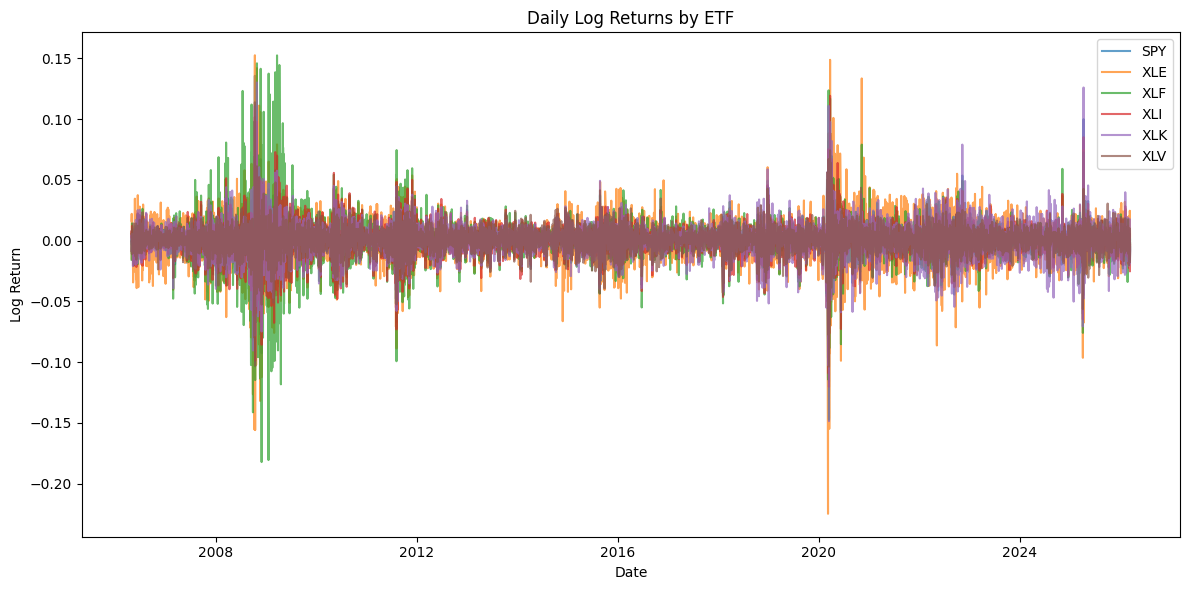

In [ ]:
plt.figure(figsize=(12, 6))
for ticker in sorted(stock_df["ticker"].unique()):
    subset = stock_df[stock_df["ticker"] == ticker]
    plt.plot(subset["date"], subset["log_return"], label=ticker, alpha=0.7)

plt.title("Daily Log Returns by ETF")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()

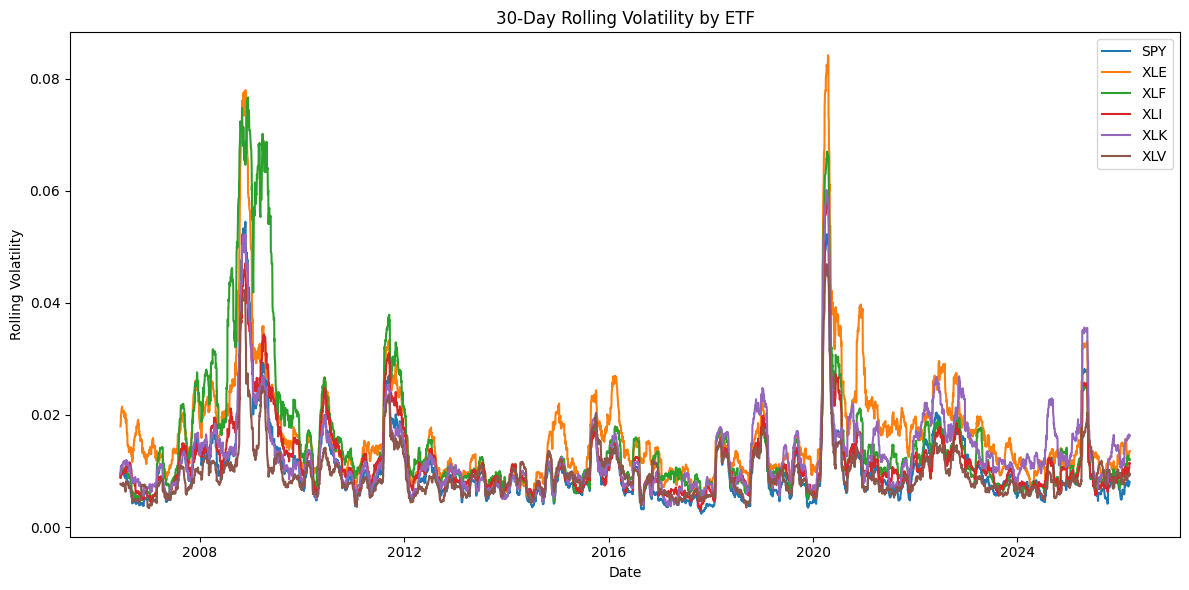

In [ ]:
plt.figure(figsize=(12, 6))
for ticker in sorted(stock_df["ticker"].unique()):
    subset = stock_df[stock_df["ticker"] == ticker]
    plt.plot(subset["date"], subset["rolling_vol_30d"], label=ticker)

plt.title("30-Day Rolling Volatility by ETF")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
avg_vol = (
    monthly.groupby("ticker")["monthly_volatility"]
    .mean()
    .sort_values(ascending=False)
)

avg_vol

ticker
XLE    0.016203
XLF    0.014472
XLK    0.012469
XLI    0.011481
SPY    0.010101
XLV    0.009371
Name: monthly_volatility, dtype: float64

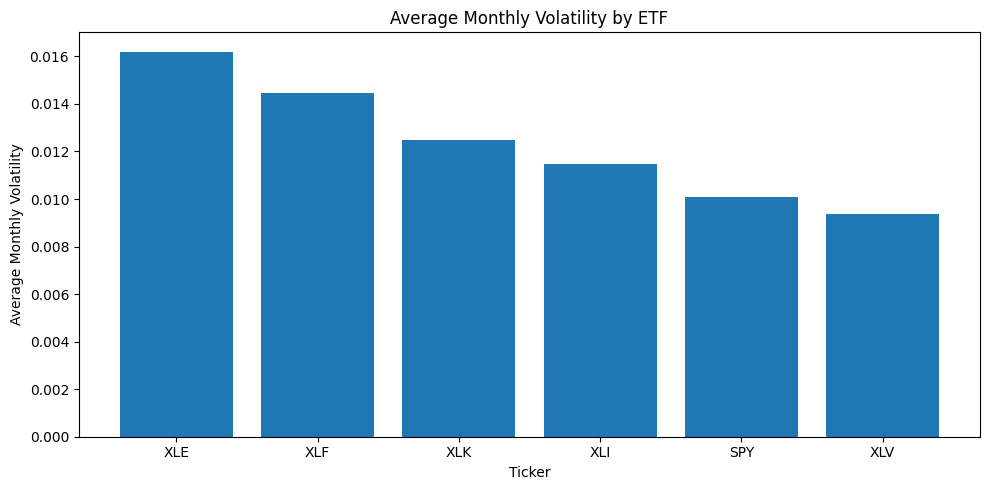

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(avg_vol.index, avg_vol.values)
plt.title("Average Monthly Volatility by ETF")
plt.xlabel("Ticker")
plt.ylabel("Average Monthly Volatility")
plt.tight_layout()
plt.show()

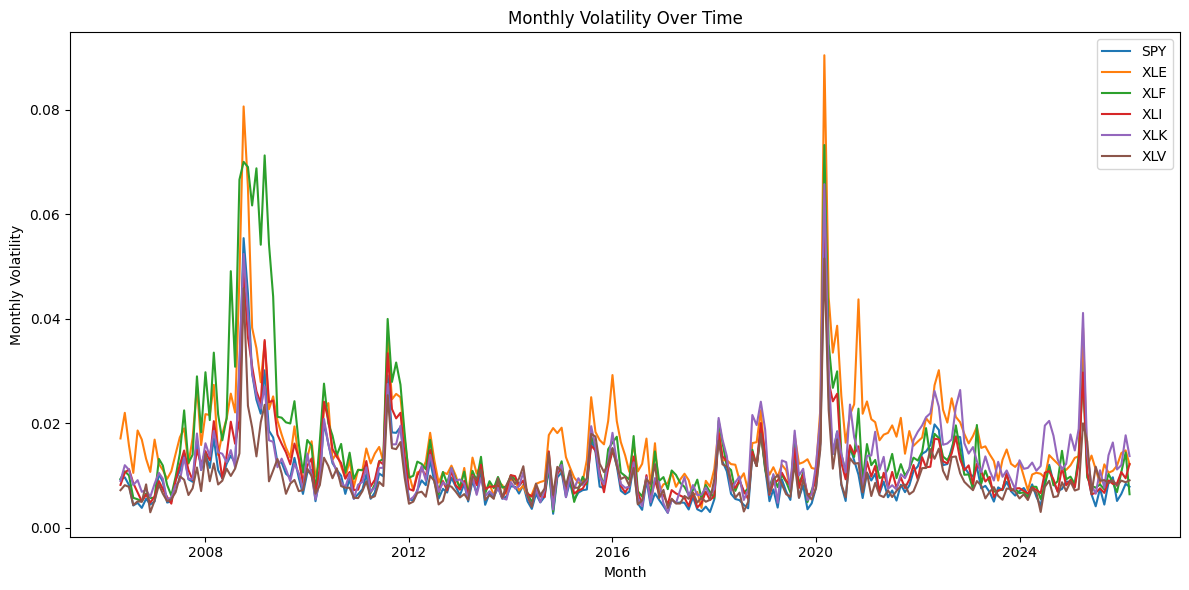

In [28]:
plt.figure(figsize=(12, 6))
for ticker in sorted(monthly["ticker"].unique()):
    subset = monthly[monthly["ticker"] == ticker].copy()
    subset["year_month"] = pd.to_datetime(subset["year_month"])
    plt.plot(subset["year_month"], subset["monthly_volatility"], label=ticker)

plt.title("Monthly Volatility Over Time")
plt.xlabel("Month")
plt.ylabel("Monthly Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
returns_wide = stock_df.pivot(index="date", columns="ticker", values="log_return")
corr_matrix = returns_wide.corr()
corr_matrix

ticker,SPY,XLE,XLF,XLI,XLK,XLV
ticker,,,,,,
SPY,1.000000,0.729933,0.842321,0.905571,0.915519,0.804848
XLE,0.729933,1.000000,0.640509,0.722059,0.575309,0.547149
XLF,0.842321,0.640509,1.000000,0.807250,0.685986,0.637748
XLI,0.905571,0.722059,0.807250,1.000000,0.784490,0.729923
XLK,0.915519,0.575309,0.685986,0.784490,1.000000,0.683617
XLV,0.804848,0.547149,0.637748,0.729923,0.683617,1.000000


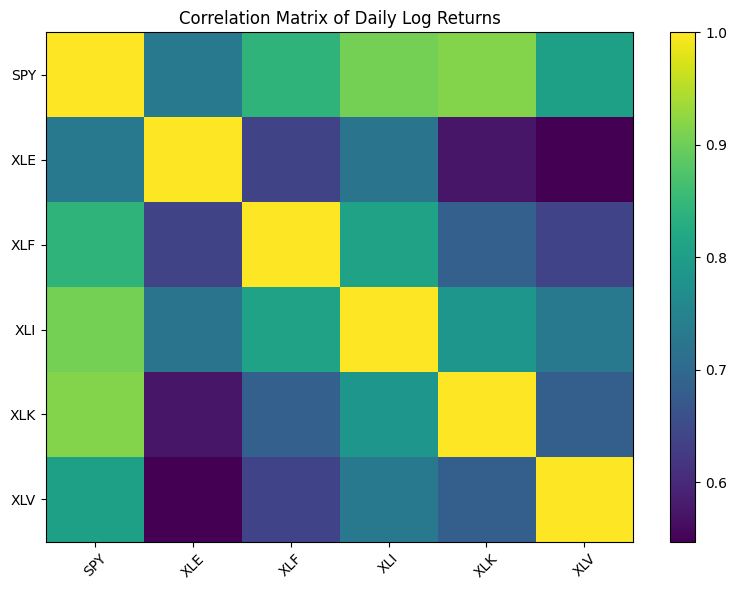

In [30]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix of Daily Log Returns")
plt.tight_layout()
plt.show()

In [31]:
monthly.sort_values("monthly_volatility", ascending=False).head(15)

,ticker,year_month,monthly_volatility,mean_daily_return,monthly_close,monthly_volume,trading_days
406,XLE,2020-03,0.090400,-0.020149,14.530000,1971094800,22
269,XLE,2008-10,0.080610,-0.009054,25.700000,2738619200,23
646,XLF,2020-03,0.073227,-0.011119,20.820000,3049399400,22
514,XLF,2009-03,0.071244,0.006715,7.156780,7841192043,22
509,XLF,2008-10,0.070014,-0.010758,12.615760,6930956421,23
510,XLF,2008-11,0.069031,-0.010754,10.284320,4443506973,19
512,XLF,2009-01,0.068777,-0.015189,7.506090,4549773414,20
508,XLF,2008-09,0.066612,-0.003529,16.157590,7904224410,21
1126,XLK,2020-03,0.065737,-0.004313,40.185000,1564823400,22
270,XLE,2008-11,0.065090,-0.001160,25.140000,1750350400,19


## FRED

In [ ]:
load_dotenv()

fred = Fred(api_key=FRED_APIKEY)

# US Economic Policy Uncertainty Index
epu = fred.get_series("USEPUINDXM")

epu.head()

1985-01-01    125.22474
1985-02-01     99.02081
1985-03-01    112.19051
1985-04-01    102.81133
1985-05-01    120.08273
dtype: float64

In [ ]:
epu_df = epu.reset_index()
epu_df.columns = ["date", "epu_index"]
epu_df["year_month"] = epu_df["date"].dt.to_period("M").astype(str)

epu_df.head()

,date,epu_index,year_month
255,2006-04-01,79.76153,2006-04
256,2006-05-01,70.83626,2006-05
257,2006-06-01,79.49433,2006-06
258,2006-07-01,80.56231,2006-07
259,2006-08-01,72.76997,2006-08


In [98]:
merged = monthly.merge(
    epu_df[["year_month","epu_index"]],
    on="year_month",
    how="left"
)

merged.head()

,ticker,year_month,monthly_volatility,mean_daily_return,monthly_close,monthly_volume,trading_days,epu_index
0,SPY,2006-05,0.009258,-0.001067,127.51,1752747100,21,70.83626
1,SPY,2006-06,0.009674,-0.000082,127.28,2163829300,22,79.49433
2,SPY,2006-07,0.008205,0.000223,127.85,1691301400,20,80.56231
3,SPY,2006-08,0.004285,0.000939,130.64,1420345400,23,72.76997
4,SPY,2006-09,0.004794,0.001113,133.58,1363687900,20,67.06754


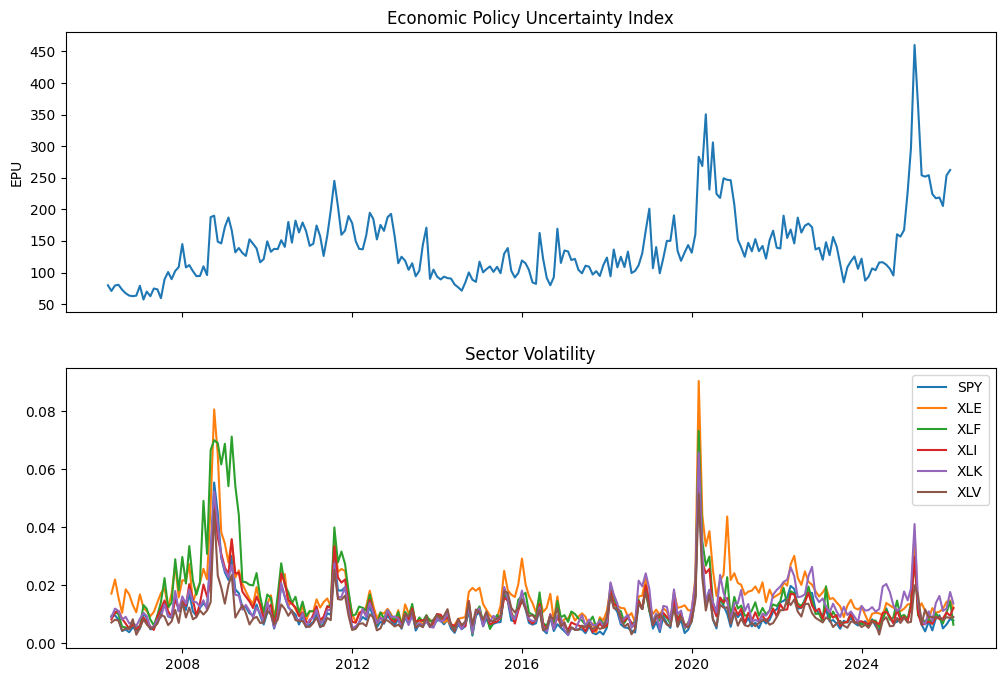

In [99]:
fig, axes = plt.subplots(2,1, figsize=(12,8), sharex=True)

# EPU
axes[0].plot(
    pd.to_datetime(epu_df["year_month"]),
    epu_df["epu_index"]
)

axes[0].set_title("Economic Policy Uncertainty Index")
axes[0].set_ylabel("EPU")

# sector volatility
for ticker in merged["ticker"].unique():
    subset = merged[merged["ticker"] == ticker]
    
    axes[1].plot(
        pd.to_datetime(subset["year_month"]),
        subset["monthly_volatility"],
        label=ticker
    )

axes[1].set_title("Sector Volatility")
axes[1].legend()

plt.show()

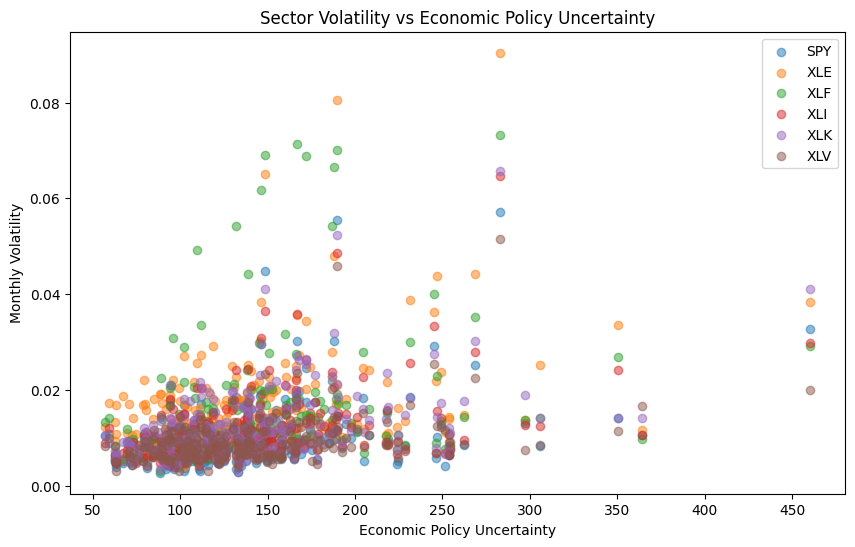

In [100]:
plt.figure(figsize=(10,6))

for ticker in merged["ticker"].unique():
    
    subset = merged[merged["ticker"] == ticker]

    plt.scatter(
        subset["epu_index"],
        subset["monthly_volatility"],
        alpha=0.5,
        label=ticker
    )

plt.xlabel("Economic Policy Uncertainty")
plt.ylabel("Monthly Volatility")
plt.title("Sector Volatility vs Economic Policy Uncertainty")
plt.legend()
plt.show()

In [101]:
corrs = (
    merged.groupby("ticker")
    .apply(lambda df: df["monthly_volatility"].corr(df["epu_index"]))
)

corrs

C:\Users\chanj\AppData\Local\Temp\ipykernel_91012\1661435385.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df["monthly_volatility"].corr(df["epu_index"]))


ticker
SPY    0.381437
XLE    0.386032
XLF    0.289481
XLI    0.415497
XLK    0.454124
XLV    0.380005
dtype: float64

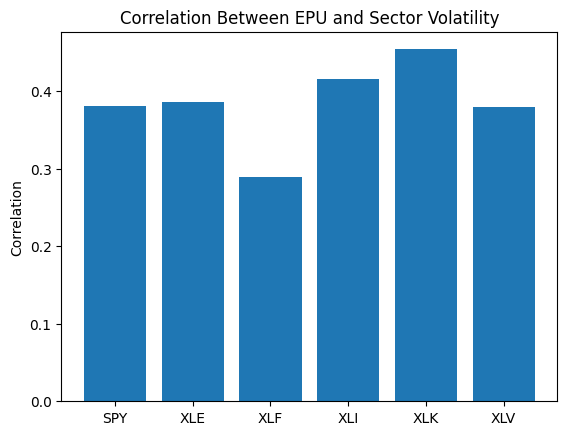

In [102]:
plt.bar(corrs.index, corrs.values)

plt.title("Correlation Between EPU and Sector Volatility")
plt.ylabel("Correlation")

plt.show()

In [103]:
merged["epu_change"] = merged.groupby("ticker")["epu_index"].diff()

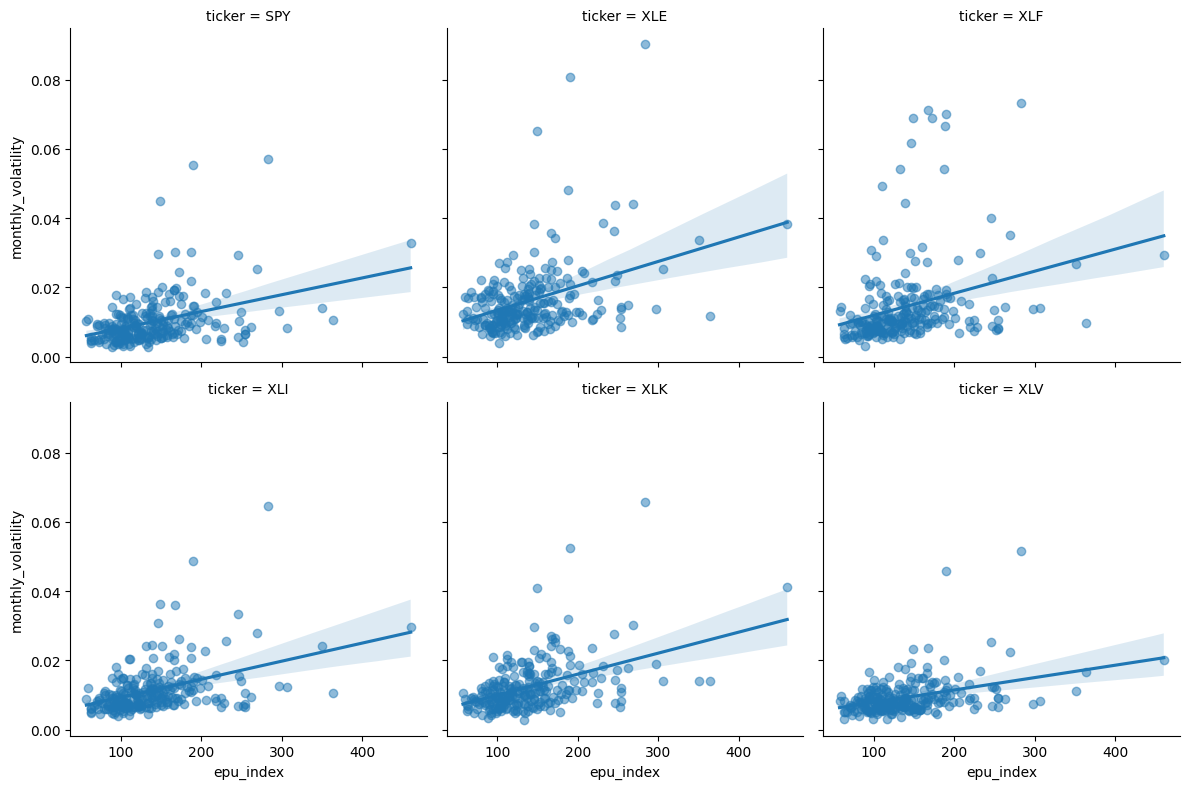

In [104]:
import seaborn as sns

sns.lmplot(
    data=merged,
    x="epu_index",
    y="monthly_volatility",
    col="ticker",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.5}
)

In [111]:
summary_table = merged[[
    "epu_index",
    "monthly_volatility",
    "mean_daily_return",
    "monthly_volume"
]].describe().loc[["mean", "std", "min", "max"]]

summary_table.round(4)

,epu_index,monthly_volatility,mean_daily_return,monthly_volume
mean,140.4730,0.0123,0.0003,9.714840e+08
std,55.7872,0.0088,0.0028,1.241097e+09
min,57.2026,0.0027,-0.0201,2.495700e+06
max,460.1143,0.0904,0.0128,1.188235e+10


In [116]:
sector_stats = (
    merged.groupby("ticker")["monthly_volatility"]
    .agg(["mean","std","min","max"])
)

sector_stats = sector_stats.round(4)

sector_stats

,mean,std,min,max
ticker,,,,
SPY,0.0101,0.0071,0.0027,0.0571
XLE,0.0162,0.0102,0.0038,0.0904
XLF,0.0145,0.0123,0.0031,0.0732
XLI,0.0115,0.0070,0.0039,0.0646
XLK,0.0125,0.0074,0.0029,0.0657
XLV,0.0094,0.0052,0.0030,0.0515


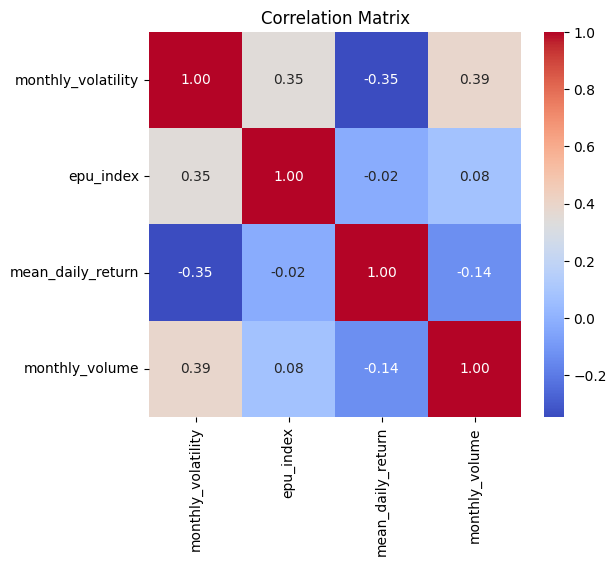

In [117]:
import seaborn as sns

corr_matrix = merged[[
    "monthly_volatility",
    "epu_index",
    "mean_daily_return",
    "monthly_volume"
]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

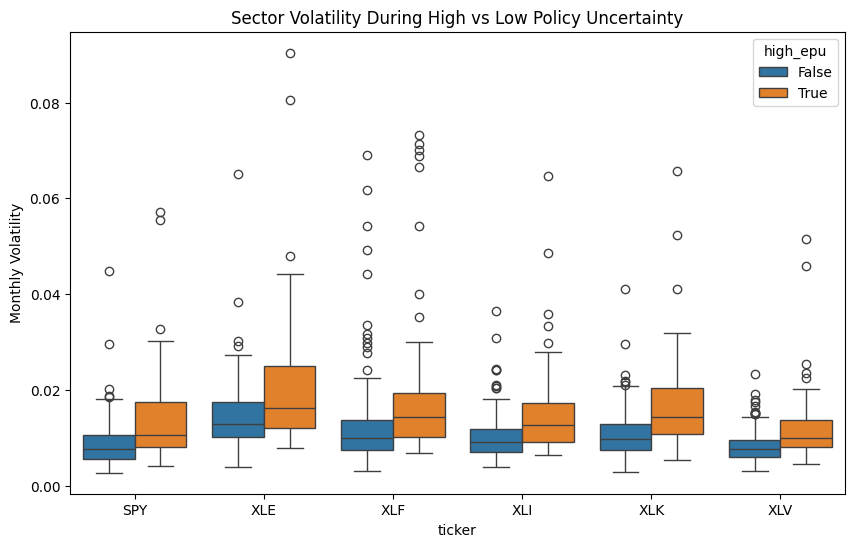

In [121]:
merged["high_epu"] = merged["epu_index"] > merged["epu_index"].quantile(0.75)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=merged,
    x="ticker",
    y="monthly_volatility",
    hue="high_epu"
)

plt.title("Sector Volatility During High vs Low Policy Uncertainty")
plt.ylabel("Monthly Volatility")

plt.show()

C:\Users\chanj\AppData\Local\Temp\ipykernel_91012\2260070089.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df["monthly_volatility"].corr(df["epu_index"]))


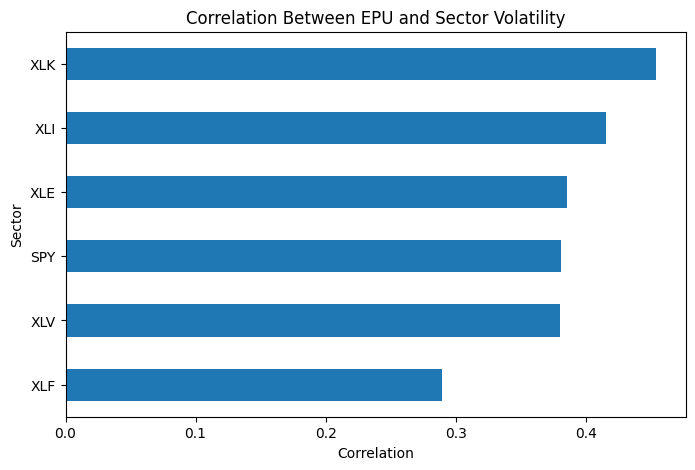

In [122]:
corrs = (
    merged.groupby("ticker")
    .apply(lambda df: df["monthly_volatility"].corr(df["epu_index"]))
)

plt.figure(figsize=(8,5))
corrs.sort_values().plot(kind="barh")

plt.title("Correlation Between EPU and Sector Volatility")
plt.xlabel("Correlation")
plt.ylabel("Sector")

plt.show()

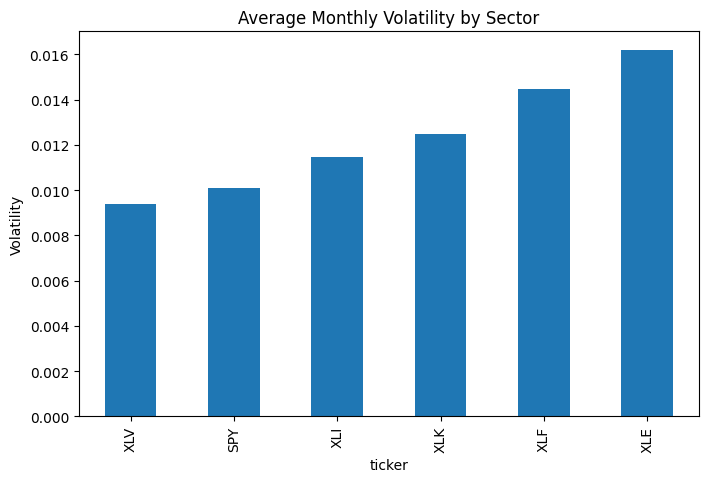

In [123]:
avg_vol = merged.groupby("ticker")["monthly_volatility"].mean()

plt.figure(figsize=(8,5))
avg_vol.sort_values().plot(kind="bar")

plt.title("Average Monthly Volatility by Sector")
plt.ylabel("Volatility")

plt.show()

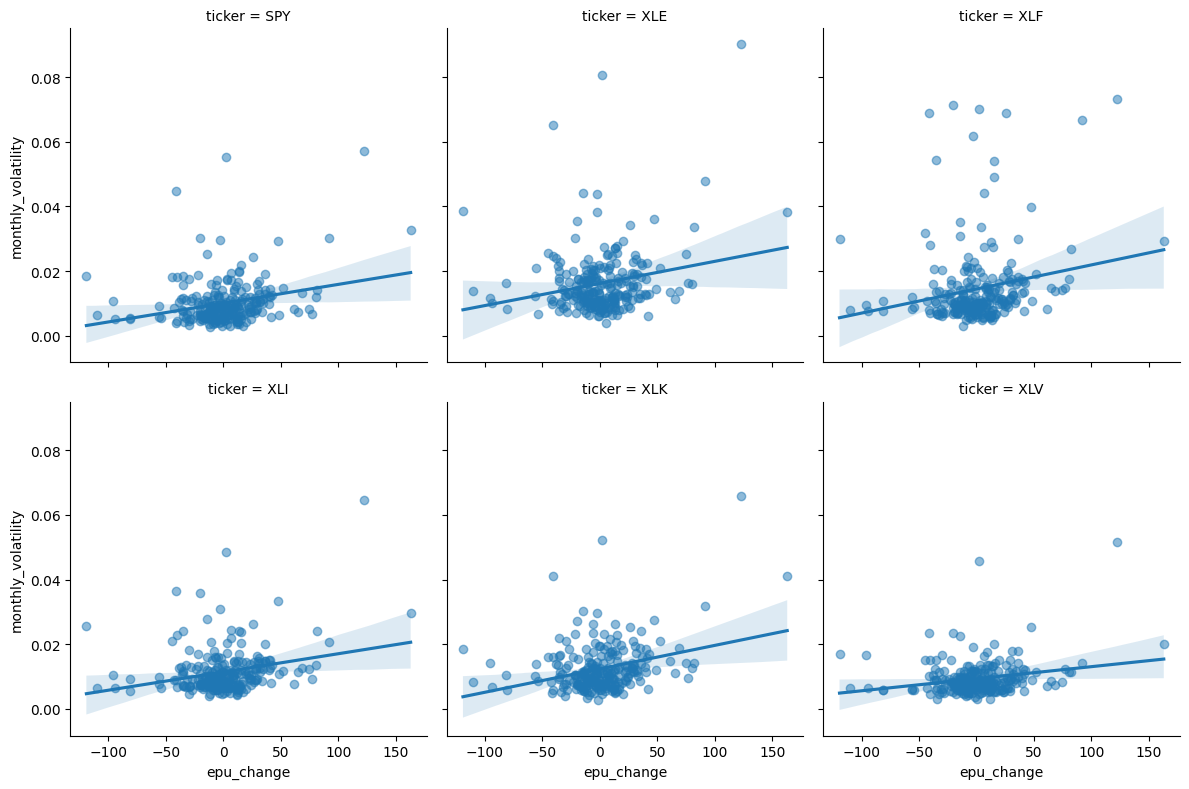

In [124]:
epu_df["epu_change"] = epu_df["epu_index"].diff()
sns.lmplot(
    data=merged,
    x="epu_change",
    y="monthly_volatility",
    col="ticker",
    col_wrap=3,
    height=4,
    scatter_kws={"alpha":0.5}
)
